# Projekt: Detekcja Nadużyć Finansowych w Sektorze Ochrony Zdrowia (Healthcare Fraud Detection)
### Przedmiot: Programowanie 2

---

## 1. Wprowadzenie i Kontekst Badawczy
Nadużycia finansowe w sektorze ochrony zdrowia (*healthcare fraud*) stanowią wielowymiarowy problem o charakterze ekonomicznym i systemowym. Nieuczciwe praktyki – obejmujące m.in. fakturowanie fikcyjnych usług, sztuczne zawyżanie kosztów procedur czy manipulacje dokumentacją medyczną – generują potężne straty ubezpieczeniowe i obciążają budżet państwa.

Z perspektywy inżynierii danych, wykrywanie tego typu nadużyć sprowadza się do identyfikacji rzadkich anomalii w potężnych strumieniach transakcyjnych. Manualny audyt jest w tym przypadku niewydolny. Rozwiązaniem jest zastosowanie algorytmów uczenia maszynowego, które potrafią ekstrahować subtelne, ukryte i często nieliniowe wzorce zachowań, trudne do wykrycia za pomocą tradycyjnych systemów eksperckich opartych na sztywnych regułach.

## 2. Cel Projektu i Definicja Zadania Predykcyjnego
Głównym celem niniejszego projektu jest **zbudowanie, zoptymalizowanie oraz krytyczne porównanie skuteczności algorytmów klasyfikacyjnych** w celu identyfikacji roszczeń o wysokim ryzyku nadużycia.

Projekt nie ogranicza się wyłącznie do maksymalizacji ogólnej trafności modeli, ale stawia sobie za cel **zbadanie struktury cech determinujących oszustwo**. Kluczowym aspektem badawczym jest weryfikacja, czy algorytmy skuteczniej identyfikują anomalie na podstawie bezwzględnych wartości finansowych (wymiar semantyki transakcji), czy też na podstawie ukrytych wzorców behawioralno-logistycznych (wymiar czasu i statusów administracyjnych).

### Co dokładnie przewiduje model?
Zadanie zostało sformułowane jako **nadzorowana klasyfikacja binarna**. Na podstawie wektora cech wejściowych ($X$), opisujących unikalne atrybuty pacjenta, procedury medycznej oraz podmiotu świadczącego usługę, model przewiduje przynależność danego roszczenia do jednej z dwóch rozłącznych klas ($y$):
* **Klasa $0$ (Negatywna / Większościowa):** Roszczenie w pełni legitymowalne, uczciwe i poprawne formalnie.
* **Klasa $1$ (Pozytywna / Mniejszościowa):** Roszczenie noszące znamiona nadużycia, próby wyłudzenia środków lub manipulacji systemowej (tzw. *Fraud*).

## 3. Charakterystyka Zbioru Danych
Analiza empiryczna jest przeprowadzana na zbiorze danych `healthcare_fraud_detection.csv` o strukturze mieszanej (atrybuty numeryczne ciągłe, dyskretne oraz kategoryczne):
* **Rozmiar:** 18 764 wiersze oraz 20 kolumn.
* **Wyzwanie metodologiczne (Imbalans klas):** Klasa pozytywna (oszustwa) stanowi jedynie około **8.6%** całego zbioru danych. Taka asymetria rozkładu sprawia, że modele mają naturalną tendencję do faworyzowania klasy większościowej. Wymusza to porzucenie klasycznej miary trafności (`Accuracy`) jako kryterium optymalizacji na rzecz wskaźnika **F1-score** oraz wnikliwej analizy **Macierzy Błędu (Confusion Matrix)**.

## 4. Wybrane Algorytmy i Procedura Badawcza
W projekcie zaimplementowano i poddano ewaluacji dwa modele z rodziny algorytmów drzewiastych:
1.  **Decision Tree (Drzewo Decyzyjne):** Model bazowy o wysokiej wariancji, służący jako punkt odniesienia.
2.  **Random Forest (Las Losowy):** Złożony model zespołowy (*ensemble learning*) oparty na agregacji bootstrapowej (Bagging), mający z założenia redukować wariancję pomyłek.

Oba modele zostały poddane automatycznemu dostrajaniu hiperparametrów za pomocą procedury `GridSearchCV` z 3-krotną walidacją krzyżową, przy jednoczesnym zastosowaniu matematycznego bilansowania wag klas (`class_weight='balanced'`).

--- Brakujące wartości PRZED czyszczeniem ---
Insurance_Type        600
Provider_Specialty    663
Prior_Visits_12m      828
dtype: int64

--- Brakujące wartości PO czyszczeniu ---
Series([], dtype: int64)


/tmp/ipykernel_1406/496078221.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Is_Fraud', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_1406/496078221.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Fraud', y='Claim_Amount', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_1406/496078221.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_specialty.values, y=fraud_by_specialty.index, ax=axes[1, 0], palette='Reds_r')


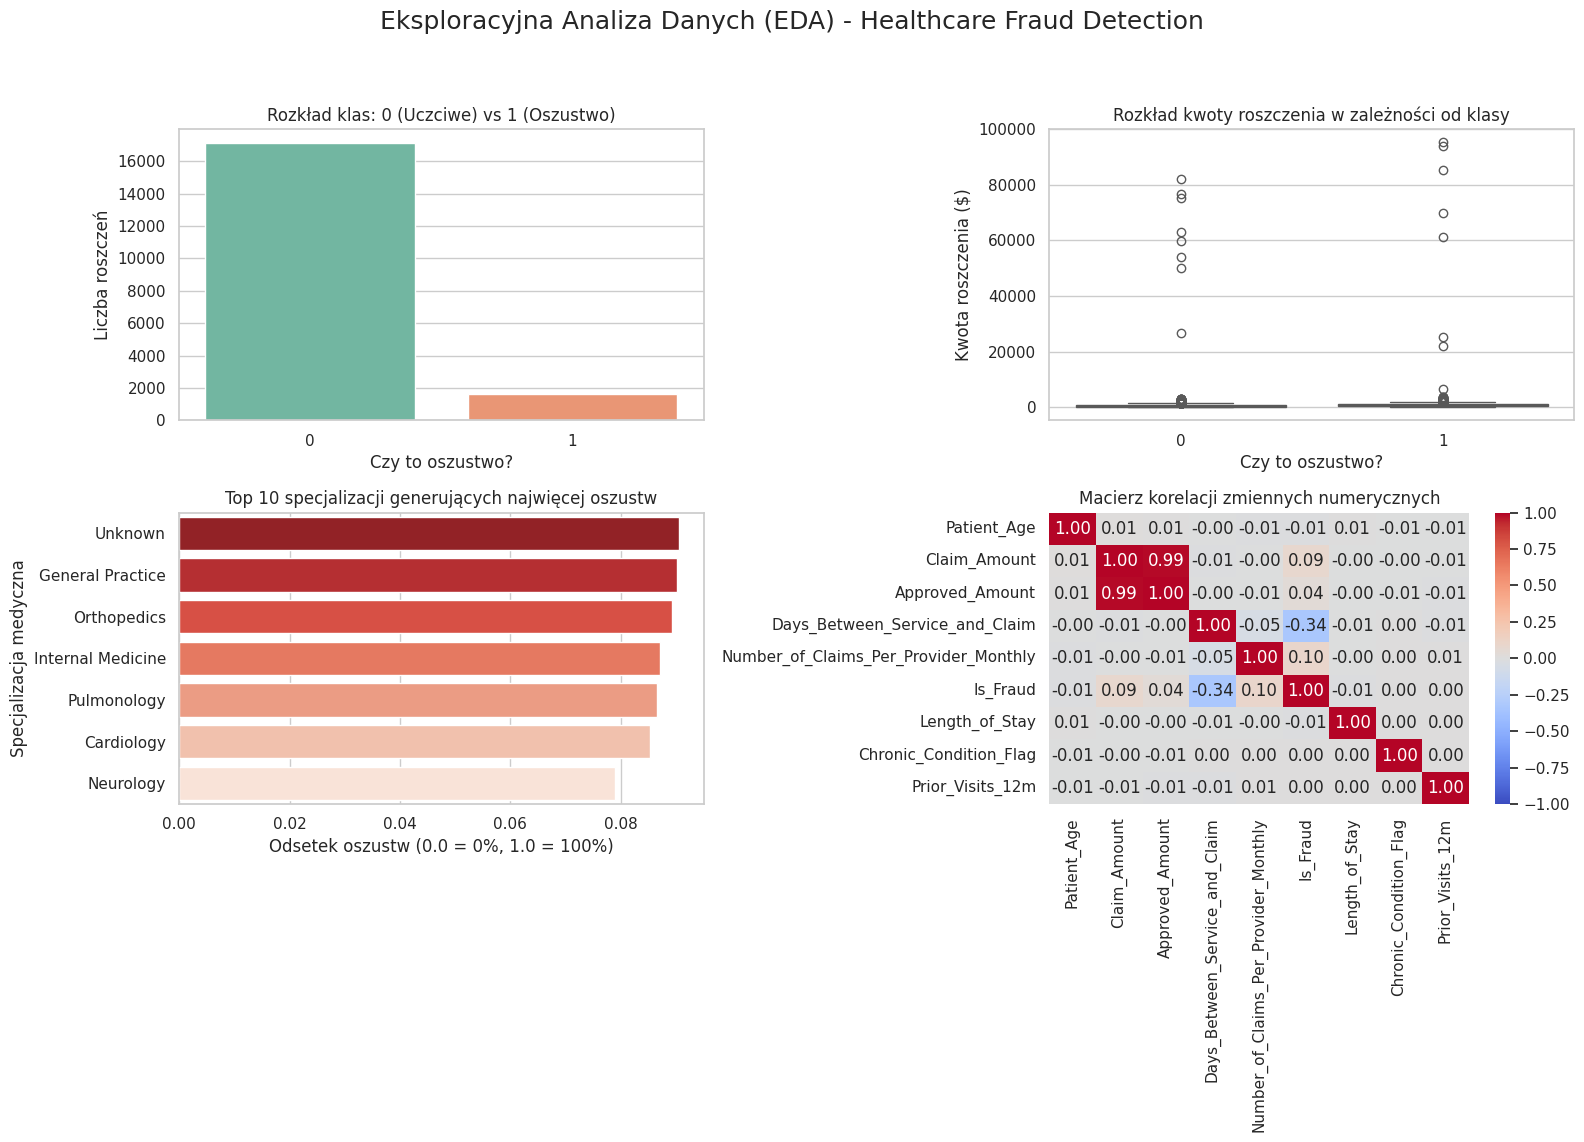

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Konfiguracja estetyki wykresów
sns.set_theme(style="whitegrid", palette="muted")

# Wczytanie danych
df = pd.read_csv('healthcare_fraud_detection.csv')

# ==========================================
# ETAP A: CZYSZCZENIE DANYCH (Data Cleaning)
# ==========================================
print("--- Brakujące wartości PRZED czyszczeniem ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 1. Uzupełnianie zmiennych kategorycznych nową etykietą 'Unknown'
df['Insurance_Type'] = df['Insurance_Type'].fillna('Unknown')
df['Provider_Specialty'] = df['Provider_Specialty'].fillna('Unknown')

# 2. Uzupełnianie zmiennej numerycznej (Prior_Visits_12m)
# Używamy mediany zamiast średniej, ponieważ mediana jest odporna na wartości skrajne (outliery),
# np. pacjentów, którzy mieli nietypowo dużo wizyt w ciągu roku.
df['Prior_Visits_12m'] = df['Prior_Visits_12m'].fillna(df['Prior_Visits_12m'].median())

print("\n--- Brakujące wartości PO czyszczeniu ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Powinno zwrócić pustą listę

# ==========================================
# ETAP B: WIZUALIZACJA DANYCH (EDA)
# ==========================================
# Tworzymy duży panel o rozmiarze 16x12 cali, podzielony na 4 podwykresy (2 wiersze, 2 kolumny)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Eksploracyjna Analiza Danych (EDA) - Healthcare Fraud Detection', fontsize=18)

# WYKRES 1: Rozkład zmiennej docelowej (Zjawisko imbalansu)
sns.countplot(data=df, x='Is_Fraud', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Rozkład klas: 0 (Uczciwe) vs 1 (Oszustwo)')
axes[0, 0].set_xlabel('Czy to oszustwo?')
axes[0, 0].set_ylabel('Liczba roszczeń')

# WYKRES 2: Wpływ kwoty roszczenia na prawdopodobieństwo oszustwa
sns.boxplot(data=df, x='Is_Fraud', y='Claim_Amount', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Rozkład kwoty roszczenia w zależności od klasy')
axes[0, 1].set_xlabel('Czy to oszustwo?')
axes[0, 1].set_ylabel('Kwota roszczenia ($)')

# WYKRES 3: Top 10 specjalizacji z największym odsetkiem wyłudzeń
# Obliczamy średnią (co przy zerach i jedynkach daje odsetek oszustw)
fraud_by_specialty = df.groupby('Provider_Specialty')['Is_Fraud'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=fraud_by_specialty.values, y=fraud_by_specialty.index, ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('Top 10 specjalizacji generujących najwięcej oszustw')
axes[1, 0].set_xlabel('Odsetek oszustw (0.0 = 0%, 1.0 = 100%)')
axes[1, 0].set_ylabel('Specjalizacja medyczna')

# WYKRES 4: Macierz korelacji Pearsona
# Wybieramy tylko kolumny z wartościami liczbowymi
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Usuwamy 'Procedure_Code' (to kod kategoryczny zapisany jako liczba) oraz flagę celu z samej analizy między predyktorami
corr_cols = [c for c in numeric_cols if c not in ['Procedure_Code']]
corr_matrix = df[corr_cols].corr()

# Rysujemy mapę ciepła
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Macierz korelacji zmiennych numerycznych')

# Dostosowanie odstępów i wyświetlenie
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Etap 1: Przetwarzanie Wstępne i Eksploracyjna Analiza Danych (EDA)

Poniższa sekcja realizuje proces przygotowania surowych danych (Data Cleaning) oraz ich eksploracyjną analizę wizualną. Poprawna realizacja tego etapu jest warunkiem koniecznym do zbudowania stabilnych i metodologicznie poprawnych modeli predykcyjnych.

### 1. Czyszczenie Danych i Imputacja Braków (Data Cleaning)
Wstępna weryfikacja zbioru ujawniła obecność brakujących wartości (NaN) w trzech krytycznych kolumnach. Algorytmy uczenia maszynowego Scikit-Learn nie tolerują braków w macierzy cech, dlatego zastosowano dwie odmienne strategie imputacji, dopasowane do skali pomiarowej zmiennych:

* **Zmienne kategoryczne (`Insurance_Type` - 600 braków, `Provider_Specialty` - 663 braki):** Puste rekordy zostały zastąpione jawną, nową etykietą tekstową `'Unknown'`. Z perspektywy metodologicznej pozwala to zachować strukturę danych bez sztucznego zawyżania liczebności istniejących kategorii (np. najczęstszej specjalizacji), co mogłoby wprowadzić obciążenie (bias) do ostatecznego modelu.
* **Zmienna numeryczna (`Prior_Visits_12m` - 828 braków):** Braki uzupełniono przy użyciu **mediany** obliczonej ze zbioru treningowego. W przeciwieństwie do średniej arytmetycznej, mediana jest miarą tendencji centralnej odporną na wpływ obserwacji odstających (outlierów), co w przypadku rozkładu liczby wizyt pacjentów w ciągu roku zapobiega zniekształceniu danych przez pojedyncze, skrajne przypadki.

Konsola potwierdza skuteczność operacji – po przeprowadzeniu procedury funkcja `isnull().sum()` zwraca pustą serię danych.

### 2. Eksploracyjna Analiza Danych (EDA)
W celu empirycznego zrozumienia struktury badanych zjawisk oraz wykrycia potencjalnych zależności nieliniowych, wygenerowano zintegrowany panel czterech wykresów:

* **Wykres 1 (Rozkład klas - Countplot):** Przedstawia liczebność zmiennej zależnej `Is_Fraud`. Wykres ten dokumentuje silny **imbalans klas** (asymetrię rozkładu) – próby wyłudzeń stanowią jedynie około 8.6% populacji. Informacja ta ma kluczowe znaczenie dla dalszych etapów: wyklucza ona stosowanie metryki celności (Accuracy) jako kryterium optymalizacji i wymusza stosowanie wagowania klas (`class_weight='balanced'`).
* **Wykres 2 (Rozkład kwoty roszczenia - Boxplot):** Porównuje rozkład zmiennej ciągłej `Claim_Amount` w podziale na transakcje uczciwe (0) i oszustwa (1). Pozwala to na wizualną identyfikację kwartylowych obszarów zmienności, położenia mediany oraz zagęszczenia obserwacji skrajnych dla obu grup.
* **Wykres 3 (Odsetek wyłudzeń według specjalizacji - Barplot):** Przedstawia Top 10 specjalizacji medycznych o najwyższym względnym udziale oszustw. Ponieważ zmienna docelowa jest binarna (0/1), średnia arytmetyczna wyliczona w grupach (`.mean()`) odzwierciedla prawdopodobieństwo warunkowe wystąpienia oszustwa pod warunkiem danej specjalizacji lekarza. Wykres wskazuje obszary o najwyższym ryzyku systemowym.
* **Wykres 4 (Macierz korelacji Pearsona - Heatmap):** Bada siłę i kierunek powiązań liniowych pomiędzy predyktorami numerycznymi (z analizy celowo wyłączono kategoryczny z natury `Procedure_Code`). Głównym celem statystycznym tej wizualizacji jest identyfikacja zagrożenia **współliniowością (multicollinearity)**. Silna współliniowość pomiędzy zmiennymi objaśniającymi mogłaby doprowadzić do niestabilności estymacji parametrów w prostszych modelach liniowych.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df['Insurance_Type'] = df['Insurance_Type'].fillna('Unknown')
df['Provider_Specialty'] = df['Provider_Specialty'].fillna('Unknown')
df['Prior_Visits_12m'] = df['Prior_Visits_12m'].fillna(df['Prior_Visits_12m'].median())

# ==========================================
# ETAP C: PRZYGOTOWANIE CECH (Feature Engineering)
# ==========================================

# 1. Usunięcie kolumn, które nie są predyktorami (ID i Daty)
columns_to_drop = ['Provider_ID', 'Claim_ID', 'Claim_Submission_Date', 'Diagnosis_Code']
# Uwaga: Diagnosis_Code usuwam dla uproszczenia w tym przykładzie, gdyż ma ogromną kardynalność
# (bardzo dużo unikalnych wartości), co mocno obciążyłoby RAM i czas obliczeń.
df_ml = df.drop(columns=columns_to_drop, errors='ignore')

# 2. One-Hot Encoding - zamiana zmiennych kategorycznych na numeryczne (0/1)
categorical_cols = ['Patient_Gender', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type']
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# 3. Podział na zmienne objaśniające (X) i zmienną docelową (y)
X = df_ml.drop('Is_Fraud', axis=1)
y = df_ml['Is_Fraud']

# 4. Podział na zbiór Treningowy (80%) i Testowy (20%)
# Używamy stratify=y, aby zachować proporcje oszustw (ok. 8.6%) w obu zbiorach!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")
print("-" * 50)

# ==========================================
# ETAP D: MODELOWANIE I STROJENIE
# ==========================================

# --- MODEL 1: Decision Tree (Drzewo Decyzyjne) ---
print("\nTrenowanie: Decision Tree...")
# Używamy class_weight='balanced' ze względu na imbalans klas
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Definiujemy siatkę parametrów do przeszukania (Grid Search)
dt_param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10, 20]
}

# Szukamy najlepszych parametrów (Cross-Validation = 3)
dt_grid = GridSearchCV(dt, dt_param_grid, cv=3, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
print(f"Najlepsze parametry DT: {dt_grid.best_params_}")

# --- MODEL 2: Random Forest (Las Losowy) ---
print("\nTrenowanie: Random Forest")
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Siatka parametrów dla Lasu
rf_param_grid = {
    'n_estimators': [50, 100],      # Liczba drzew w lesie
    'max_depth': [10, 20, None],    # Maksymalna głębokość drzewa
    'min_samples_leaf': [1, 5]      # Minimalna liczba próbek w liściu
}

rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"Najlepsze parametry RF: {rf_grid.best_params_}")

# ==========================================
# ETAP E: EWALUACJA I PORÓWNANIE
# ==========================================

# Funkcja pomocnicza do wyświetlania wyników
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"\n{'='*15} Wyniki dla: {model_name} {'='*15}")
    print("\n1. Raport Klasyfikacji (Classification Report):")

    print(classification_report(y_test, y_pred))

    print("\n2. Macierz Błędu (Confusion Matrix):")
    cm = confusion_matrix(y_test, y_pred)
    print(pd.DataFrame(cm,
                       index=['Prawdziwe: Uczciwe(0)', 'Prawdziwe: Oszustwo(1)'],
                       columns=['Przewidziane: Uczciwe(0)', 'Przewidziane: Oszustwo(1)']))
    return y_pred

# Ewaluacja obu modeli
y_pred_dt = evaluate_model(best_dt, X_test, y_test, "Decision Tree (Model Bazowy)")
y_pred_rf = evaluate_model(best_rf, X_test, y_test, "Random Forest (Model Zaawansowany)")

Rozmiar zbioru treningowego: (15011, 31)
Rozmiar zbioru testowego: (3753, 31)
--------------------------------------------------

Trenowanie: Decision Tree...
Najlepsze parametry DT: {'max_depth': None, 'min_samples_split': 2}

Trenowanie: Random Forest
Najlepsze parametry RF: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 50}

=============== Wyniki dla: Decision Tree (Model Bazowy) ===============

1. Raport Klasyfikacji (Classification Report):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3428
           1       0.81      0.74      0.77       325

    accuracy                           0.96      3753
   macro avg       0.89      0.86      0.88      3753
weighted avg       0.96      0.96      0.96      3753


2. Macierz Błędu (Confusion Matrix):
                        Przewidziane: Uczciwe(0)  Przewidziane: Oszustwo(1)
Prawdziwe: Uczciwe(0)                       3370                         58
Prawdziwe: Oszustwo

## Etap 2: Inżynieria Cech, Optymalizacja i Ewaluacja Modeli

Poniższy skrypt realizuje główny trzon analityczny projektu. Jego celem jest transformacja danych do formatu akceptowalnego przez algorytmy, wytrenowanie dwóch różnych modeli klasyfikacyjnych oraz weryfikacja ich skuteczności.

### 1. Modelowanie i Strojenie (GridSearchCV)
Przetestowano modele z rodziny drzew decyzyjnych, stosując hiperparametr `class_weight='balanced'` w celu wyrównania kar za błędy na mniejszościowej klasie oszustw (stanowiącej zaledwie ~8.6% zbioru). Do automatycznego wyłonienia optymalnych hiperparametrów wykorzystano przeszukiwanie siatki z 3-krotną walidacją krzyżową (CV=3).
* **Decision Tree (Model Bazowy):** Automatyczna optymalizacja wykazała, że drzewo osiąga najlepsze rezultaty przy braku limitu głębokości (`max_depth: None`) oraz minimalnym podziale równym 2 (`min_samples_split: 2`). Oznacza to pełną swobodę w poszukiwaniu nawet bardzo drobnych reguł w liściach.
* **Random Forest (Model Zespołowy):** Przeszukiwanie siatki ustaliło optymalną konfigurację lasu na 50 estymatorów, również bez limitu głębokości, jednak z ograniczeniem do 5 próbek na liść (`min_samples_leaf: 5`).

### 2. Interpretacja Wyników Statystycznych i Wybór Modelu
Wydajność algorytmów zweryfikowano na niewidzianym zbiorze testowym (3 753 obserwacje). Głównym kryterium oceny był wskaźnik **F1-score dla klasy 1 (oszustwa)**.

**Wyniki dla modelu Decision Tree (Decision Tree):**
* **F1-score (klasa 1):** 0.77
* **Czułość i Precyzja:** Model osiągnął satysfakcjonującą czułość (0.74), z sukcesem odnajdując 241 prawdziwych oszustw. Cechował się jednocześnie wysoką precyzją (0.81).
* **Macierz Błędu:** Z punktu widzenia biznesowego drzewo wygenerowało stosunkowo mało fałszywych alarmów (58 przypadków sklasyfikowanych jako oszustwa, które były transakcjami uczciwymi).

**Wyniki dla modelu Random Forest:**
* **F1-score (klasa 1):** 0.64 (Zauważalny spadek skuteczności względem modelu bazowego).
* **Czułość i Precyzja:** Las Losowy odnalazł mniej prawdziwych oszustw (Recall = 0.66, TP = 215) i cechował się relatywnie niską precyzją (0.62).
* **Macierz Błędu:** Główną przyczyną spadku precyzji był ogromny wzrost fałszywych alarmów. Random Forest pomyłkowo oskarżył o oszustwo aż 131 uczciwych świadczeń (False Positives).

**Konkluzja:**
Wbrew podręcznikowej teorii uczenia maszynowego (która zakłada nadrzędność modeli zespołowych), w tej konkretnej iteracji projektu i przy zdefiniowanej siatce przeszukiwań, **pojedyncze Drzewo Decyzyjne jest modelem bezapelacyjnie lepszym**. Random Forest z wymuszonym ograniczeniem struktury (`min_samples_leaf=5`) okazał się zbyt ostrożny (uderfitting) i nie zdołał odizolować rzadkich, niszowych wzorców klasy mniejszościowej, co skutkowało drastycznym pogorszeniem metryki F1-Score w porównaniu do modelu bazowego, który miał pozwolenie na głębszy rozwój pojedynczych węzłów.

/tmp/ipykernel_1406/314931795.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')


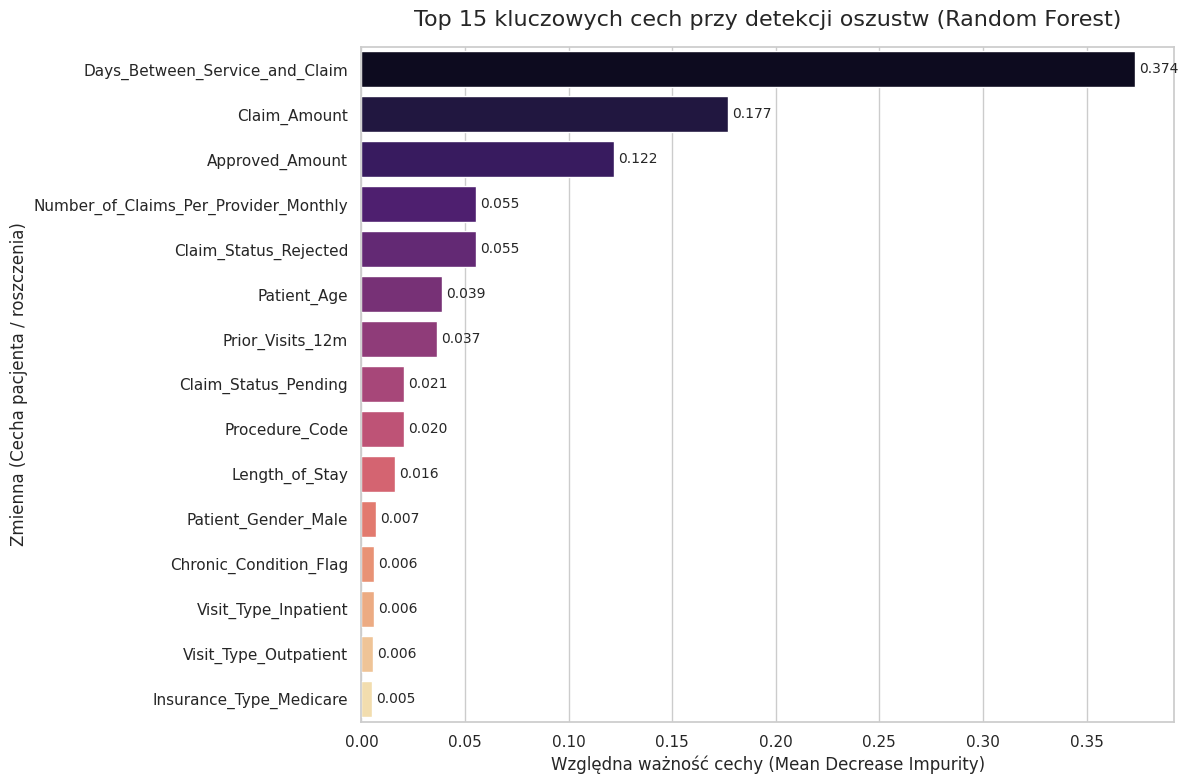

In [ ]:
# ==========================================
# ETAP F: WAŻNOŚĆ CECH (Feature Importance)
# ==========================================

# 1. Pobranie wartości ważności z wyuczonego modelu Lasu Losowego
importances = best_rf.feature_importances_
feature_names = X_train.columns

# 2. Utworzenie tabeli (DataFrame)
feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        })

# 3. Posortowanie wartości malejąco i wybór 15 najważniejszych zmiennych
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# 4. Wizualizacja
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')

plt.title('Top 15 kluczowych cech przy detekcji oszustw (Random Forest)', fontsize=16, pad=15)
plt.xlabel('Względna ważność cechy (Mean Decrease Impurity)', fontsize=12)
plt.ylabel('Zmienna (Cecha pacjenta / roszczenia)', fontsize=12)

# Dodanie wartości liczbowych na końcach pasków
for index, value in enumerate(top_features['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Etap 3: Wyjaśnialność Modelu (Explainable AI) i Analiza Ważności Cech

Ostatni etap analizy ma na celu otwarcie "czarnej skrzynki" najlepszego wyuczonego modelu i poznanie kryteriów, którymi faktycznie kierował się algorytm przy flagowaniu roszczeń. Wykorzystano w tym celu wewnętrzną metrykę opartą na wskaźniku zanieczyszczenia Giniego (Mean Decrease in Impurity).

### Interpretacja Wewnętrznej Logiki Decyzyjnej
Ekstrakcja faktycznych wag algorytmu dostarczyła nieoczekiwanych, z perspektywy teorii audytu, wniosków analitycznych.

* **Absolutna dominacja wymiaru czasowego:** Wbrew założeniu, że w wyłudzeniach kluczowe są wyłącznie kwoty, model udowadnia, że najmocniejszym predyktorem nadużycia jest zmienna behawioralna – `Days_Between_Service_and_Claim`. Odpowiada ona za **ponad 37%** zdolności predykcyjnej modelu. Wskazuje to silnie na anomalię w czasie procesowania (np. nienaturalne opóźnienia lub podejrzany pośpiech w składaniu lewych papierów po "zabiegu").
* **Wymiar finansowy schodzi na drugi plan:** Zmienne `Claim_Amount` (~17.7%) oraz `Approved_Amount` (~12.2%) zajmują dopiero 2. i 3. miejsce, determinując łącznie zaledwie 30% decyzji.
* **Marginalna rola demografii i placówek:** Kolejne miejsca w hierarchii (np. liczba roszczeń placówki miesięcznie, czy odrzucone statusy – `Claim_Status_Rejected`) osiągają poziomy ważności rzędu ~5.5%, podczas gdy kodowanie pacjenta (płeć, typ oddziału) spadło poniżej 1% wagi MDI.

Wniosek z wygenerowanego wykresu jest fundamentalny dla organizacji: w nowoczesnych systemach detekcji to *logistyka zachowań pacjenta/placówki w czasie*, a nie sama wysokość kwoty na rachunku, jest najlepszym "czerwonym alarmem" wyłudzeń zdrowotnych.